In [1]:
import mne
from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path
import config
from scipy.io import loadmat
import pandas as pd
import numpy as np

## Define paths

In [2]:

root = Path(config.BIDS_ROOT)
sub = "sub-01"
eeg_dir = root / sub / "eeg"

bdf_path = eeg_dir / f"{sub}_task-RPS_eeg.bdf"
events_tsv = eeg_dir / f"{sub}_task-RPS_events.tsv"

biosemi_file = root/ "biosemi64.mat"

## Read data

In [3]:
raw = mne.io.read_raw_bdf(bdf_path, preload=True)

Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761\sub-01\eeg\sub-01_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...


## Downsampling

In [4]:
raw.resample(sfreq=256)
raw.set_eeg_reference("average")

Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawBDF | sub-01_task-RPS_eeg.bdf, 143 x 939264 (3669.0 s), ~1.00 GiB, data loaded>

## Split into two persons

In [5]:
# Player1 has incorrectly the channels 2-... and Player2 the channels 1-...
raw_p1 = raw.copy().pick_channels([ch for ch in raw.ch_names if ch.startswith("2-")])
#raw_p2 = raw.copy().pick_channels([ch for ch in raw.ch_names if ch.startswith("1-")])

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


## Renaming Channels

In [6]:
def remove_prefix_and_rename(raw_obj, prefix):
    mapping = {}
    for ch in raw_obj.ch_names:
        mapping[ch] = ch.replace(prefix, "")
    raw_obj.rename_channels(mapping)

remove_prefix_and_rename(raw_p1, "2-")

raw_p1.rename_channels(config.channel_labels)
raw_p1.set_channel_types(config.channel_types)

C:\Users\hugoh\AppData\Local\Temp\ipykernel_29084\3051965619.py:10: RuntimeWarning: The unit for channel(s) Erg1, Erg2, Plet has changed from V to NA.
  raw_p1.set_channel_types(config.channel_types)
C:\Users\hugoh\AppData\Local\Temp\ipykernel_29084\3051965619.py:10: RuntimeWarning: The unit for channel(s) Temp has changed from V to C.
  raw_p1.set_channel_types(config.channel_types)
C:\Users\hugoh\AppData\Local\Temp\ipykernel_29084\3051965619.py:10: RuntimeWarning: The unit for channel(s) GSR1, GSR2 has changed from V to S.
  raw_p1.set_channel_types(config.channel_types)


<RawBDF | sub-01_task-RPS_eeg.bdf, 71 x 939264 (3669.0 s), ~508.8 MiB, data loaded>

## Load MAT file and map to channels

In [48]:
#mat = loadmat(biosemi_file)
#coords = mat["biosemi64"]/13.5

#ch_pos = dict(zip(config.channel_labels.values(), coords))

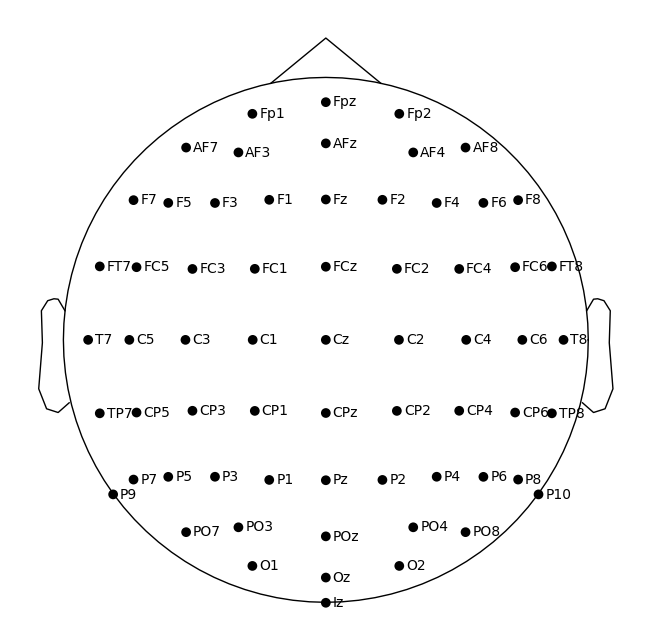

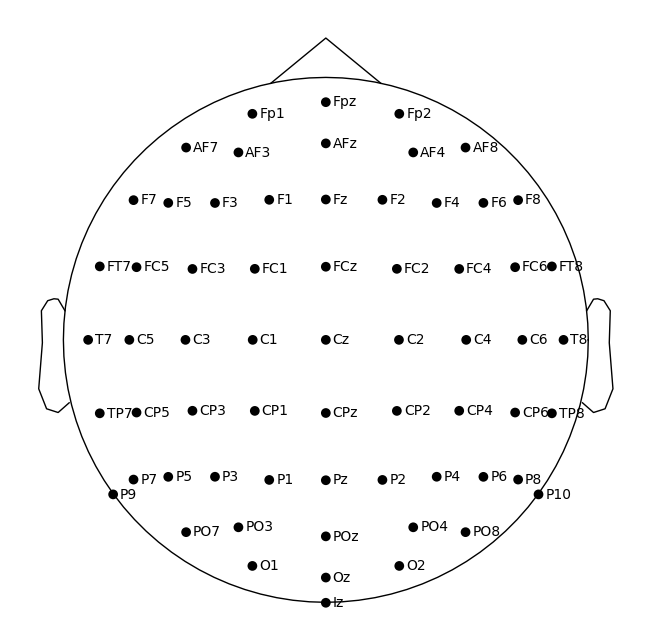

In [7]:
#montage = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame="head")
montage = mne.channels.make_standard_montage("biosemi64", head_size=0.105)
raw_p1.set_montage(montage)

raw_p1.plot_sensors(show_names=True)


## Events

In [8]:
events_df = pd.read_csv(events_tsv, sep="\t")
behav = events_df[["player1_resp", "player2_resp", "outcome"]].copy()
behav["self_prev"] = behav["player1_resp"].shift(1)
behav["other_prev"] = behav["player2_resp"].shift(1)
print(events_df.columns)

Index(['onset', 'duration', 'onset_sample', 'trial_num', 'player1_resp',
       'player1_rt', 'player2_resp', 'player2_rt', 'outcome'],
      dtype='str')


In [9]:
event_id = {
    "rock": 1,
    "paper": 2,
    "scissors": 3
}

sfreq = raw_p1.info["sfreq"]
events = np.array([
        [int(row["onset"]*sfreq), 0, row["player1_resp"]]
        for _, row in events_df.iterrows()
    ], dtype=int)


## Epochen

In [14]:
epochs = mne.Epochs(
    raw_p1,
    events=events,
    event_id=event_id,
    tmin=-0.2,
    tmax=5.0,
    baseline=(-0.2, 0),
    preload=True,
    metadata=behav
)

print(epochs)

Adding metadata with 5 columns
480 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 1332 original time points ...
0 bad epochs dropped
<Epochs | 480 events (all good), -0.199 – 5 s (baseline -0.2 – 0 s), ~346.4 MiB, data loaded, with metadata,
 'rock': 172
 'paper': 146
 'scissors': 162>


In [15]:
remove_idx = np.arange(0, len(epochs), 40)
epochs = epochs.drop(remove_idx)

Dropped 12 epochs: 0, 40, 80, 120, 160, 200, 240, 280, 320, 360, 400, 440


In [16]:
ep_decision = epochs.copy().crop(-0.2, 2.0)
ep_response = epochs.copy().crop(1.8, 4.0)
ep_feedback = epochs.copy().crop(3.8, 5.0)

C:\Users\hugoh\AppData\Local\Temp\ipykernel_29084\2044329346.py:1: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-0.199219 s)
  ep_decision = epochs.copy().crop(-0.2, 2.0)


In [27]:
tDecision = ep_decision.times
ep_response._set_times(tDecision)
ep_feedback._set_times(tDecision[:ep_feedback.get_data().shape[2]])

In [28]:
def bin_epochs(ep, bins):
    X = ep.get_data()  # (trials, channels, time)
    times = ep.times
    binned = []

    for tmin, tmax in bins:
        mask = (times >= tmin) & (times < tmax)
        binned.append(X[:, :, mask].mean(axis=2))

    return np.stack(binned, axis=2)  # (trials, channels, bins)

In [29]:
bins_AB = [(i, i+0.25) for i in np.arange(0, 2, 0.25)]
bins_C  = [(i, i+0.25) for i in np.arange(0, 1, 0.25)]

In [38]:
decision = bin_epochs(ep_decision, bins_AB)
response = bin_epochs(ep_response, bins_AB)
feedback = bin_epochs(ep_feedback, bins_C)

In [45]:
X = np.concatenate([decision, response, feedback], axis=2)  # (trials, channels, total_bins)
X = X.reshape(X.shape[0], -1)  # (trials, features)

y_self = ep_decision.metadata["player1_resp"].to_numpy()
mask = y_self > 0
epochs_decision = ep_decision[mask]
y_self = y_self[mask]
X_dec = ep_decision.get_data()

In [46]:
from mne.decoding import SlidingEstimator, cross_val_multiscore
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold

clf = LinearDiscriminantAnalysis()

time_decod = SlidingEstimator(
    clf,
    scoring="accuracy",
    n_jobs=1
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_multiscore(time_decod, X_dec, y_self, cv=cv)
mean_scores = scores.mean(axis=0)


100%|██████████| Fitting SlidingEstimator : 564/564 [00:06<00:00,   88.30it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:06<00:00,   90.32it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:06<00:00,   93.28it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:06<00:00,   92.53it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:06<00:00,   92.86it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:05<00:00,   95.22it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:05<00:00,   99.38it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:05<00:00,   96.77it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:05<00:00,   95.59it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:05<00:00,   96.93it/s]


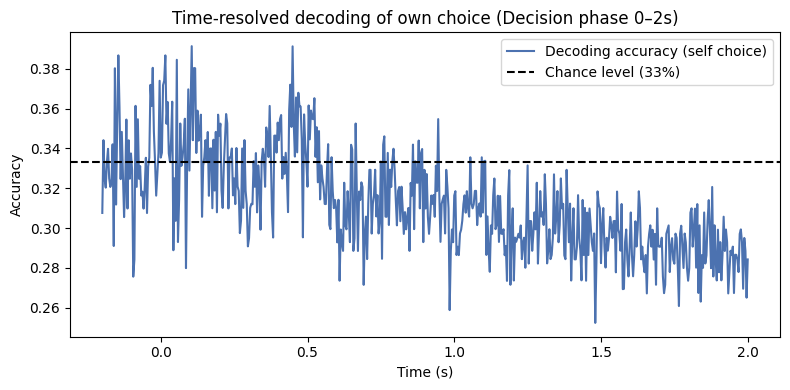

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ep_decision.times, mean_scores, label="Decoding accuracy (self choice)", color="#4C72B0")
plt.axhline(1/3, color="k", linestyle="--", label="Chance level (33%)")

plt.xlabel("Time (s)")
plt.ylabel("Accuracy")
plt.title("Time‑resolved decoding of own choice (Decision phase 0–2s)")
plt.legend()
plt.tight_layout()
plt.show()


# Many subjects

Processing sub-01...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761/sub-01/eeg/sub-01_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 5 columns
480 matching events found
Applying baseline correction (mode

100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   82.34it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   79.86it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   83.40it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   77.16it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   79.67it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   84.51it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   85.43it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   81.69it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   82.73it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   86.31it/s]


Processing sub-02...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761/sub-02/eeg/sub-02_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7020543  =      0.000 ...  3428.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 5 columns
472 matching events found
Applying baseline correction (mode

100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   93.53it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   86.53it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   83.29it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   96.88it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   93.49it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   91.59it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   92.75it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,  101.75it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   96.25it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   90.75it/s]


Processing sub-03...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761/sub-03/eeg/sub-03_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7712767  =      0.000 ...  3766.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
483 events found on stim channel Status
Event IDs: [  511  4351 15103]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
483 events found on stim channel Status
Event IDs: [  511  4351 15103]
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 5 columns
478 matching events found
Applyi

100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   84.96it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   88.01it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   91.00it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   87.09it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   82.19it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   82.62it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   88.16it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   88.14it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:05<00:00,   85.89it/s]
100%|██████████| Fitting SlidingEstimator : 513/513 [00:06<00:00,   82.06it/s]


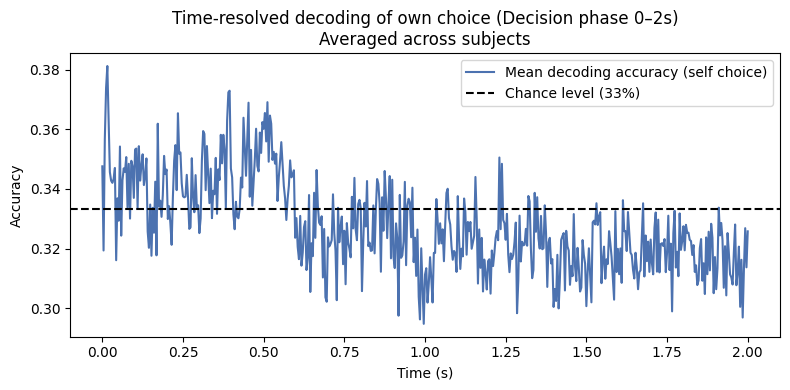

In [52]:
import mne
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from mne.decoding import SlidingEstimator, cross_val_multiscore
import matplotlib.pyplot as plt


subjects = ["sub-01", "sub-02", "sub-03"]
root = Path(config.BIDS_ROOT)

all_scores = []

for sub in subjects:
    print(f"Processing {sub}...")

    eeg_dir = f"{root}/{sub}/eeg"
    bdf_path = f"{eeg_dir}/{sub}_task-RPS_eeg.bdf"
    events_tsv = f"{eeg_dir}/{sub}_task-RPS_events.tsv"

    # -----------------------------
    # Rohdaten laden
    # -----------------------------
    raw = mne.io.read_raw_bdf(bdf_path, preload=True)
    raw.resample(256)
    raw.set_eeg_reference("average")
    raw_p1 = raw.copy().pick_channels([ch for ch in raw.ch_names if ch.startswith("2-")])

    def remove_prefix_and_rename(raw_obj, prefix):
        mapping = {}
        for ch in raw_obj.ch_names:
            mapping[ch] = ch.replace(prefix, "")
        raw_obj.rename_channels(mapping)

    remove_prefix_and_rename(raw_p1, "2-")

    raw_p1.rename_channels(config.channel_labels)
    #raw_p1.set_channel_types(config.channel_types)

    montage = mne.channels.make_standard_montage("biosemi64", head_size=0.105)
    raw_p1.set_montage(montage, on_missing="ignore")

    # -----------------------------
    # Events + Metadata laden
    # -----------------------------
    events_df = pd.read_csv(events_tsv, sep="\t")

    # Behavior-Metadata wie im Paper
    behav = events_df[["player1_resp", "player2_resp", "outcome"]].copy()
    behav["self_prev"] = behav["player1_resp"].shift(1)
    behav["other_prev"] = behav["player2_resp"].shift(1)

    # Events für MNE
    sfreq = raw_p1.info["sfreq"]
    events = np.array([
        [int(row["onset"] * sfreq), 0, row["player1_resp"]]
        for _, row in events_df.iterrows()
    ], dtype=int)

    event_id = {"rock": 1, "paper": 2, "scissors": 3}

    # -----------------------------
    # Epochs: -0.2 bis 5.0 (wie MATLAB)
    # -----------------------------
    epochs = mne.Epochs(
        raw_p1,
        events=events,
        event_id=event_id,
        tmin=-0.2,
        tmax=5.0,
        baseline=(-0.2, 0),
        preload=True,
        metadata=behav
    )

    # -----------------------------
    # Blockanfänge entfernen (1,41,81,...)
    # -----------------------------
    remove_idx = np.arange(0, len(epochs), 40)
    epochs = epochs.drop(remove_idx)

    # -----------------------------
    # Decision-Phase extrahieren (0–2s)
    # -----------------------------
    ep_dec = epochs.copy().crop(0.0, 2.0)

    # Labels: eigene Wahl
    y = ep_dec.metadata["player1_resp"].to_numpy()

    # No-responses entfernen
    mask = y > 0
    ep_dec = ep_dec[mask]
    y = y[mask]

    # Feature-Matrix
    X = ep_dec.get_data()  # (trials, channels, time)
    times = ep_dec.times

    # -----------------------------
    # SlidingEstimator (zeitaufgelöst)
    # -----------------------------
    clf = LinearDiscriminantAnalysis()
    time_decod = SlidingEstimator(clf, scoring="accuracy", n_jobs=1)
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    scores = cross_val_multiscore(time_decod, X, y, cv=cv)
    mean_scores = scores.mean(axis=0)

    # Speichern
    all_scores.append(mean_scores)

# ------------------------------------------------------------
# 3) Über alle Subjects mitteln
# ------------------------------------------------------------
all_scores = np.array(all_scores)  # shape: (subjects, timepoints)
grand_avg = all_scores.mean(axis=0)

# ------------------------------------------------------------
# 4) Plot wie im Paper
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(times, grand_avg, label="Mean decoding accuracy (self choice)", color="#4C72B0")
plt.axhline(1/3, color="k", linestyle="--", label="Chance level (33%)")

plt.xlabel("Time (s)")
plt.ylabel("Accuracy")
plt.title("Time‑resolved decoding of own choice (Decision phase 0–2s)\nAveraged across subjects")
plt.legend()
plt.tight_layout()
plt.show()



# Uneccessary bullshit

In [32]:
meta = epochs.metadata.reset_index(drop=True)

y_self = meta["player1_resp"].to_numpy()
y_other = meta["player2_resp"].to_numpy()
y_self_prev = meta["self_prev"].to_numpy()
y_other_prev = meta["other_prev"].to_numpy()

In [33]:
mask = y_self > 0
X = X[mask]
y_self = y_self[mask]
y_other = y_other[mask]
y_self_prev = y_self_prev[mask]
y_other_prev = y_other_prev[mask]

In [34]:
def average_samples(X, y, count=4, repeats=20):
    X_new, y_new = [], []
    rng = np.random.default_rng(1)

    for _ in range(repeats):
        idx = rng.choice(len(X), size=(len(X)//count, count), replace=False)
        X_avg = X[idx].mean(axis=1)
        y_avg = y[idx][:, 0]
        X_new.append(X_avg)
        y_new.append(y_avg)

    return np.vstack(X_new), np.hstack(y_new)


In [35]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

cv = StratifiedKFold(10, shuffle=True, random_state=1)

def decode(X, y):
    acc = []
    for train, test in cv.split(X, y):
        clf.fit(X[train], y[train])
        pred = clf.predict(X[test])
        acc.append(accuracy_score(y[test], pred))
    return np.mean(acc)


In [36]:
X_self, y_self2 = average_samples(X, y_self)
acc_self = decode(X_self, y_self2)

X_other, y_other2 = average_samples(X, y_other)
acc_other = decode(X_other, y_other2)

X_selfp, y_selfp2 = average_samples(X, y_self_prev)
acc_self_prev = decode(X_selfp, y_selfp2)

X_otherp, y_otherp2 = average_samples(X, y_other_prev)
acc_other_prev = decode(X_otherp, y_otherp2)


c:\Users\hugoh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(


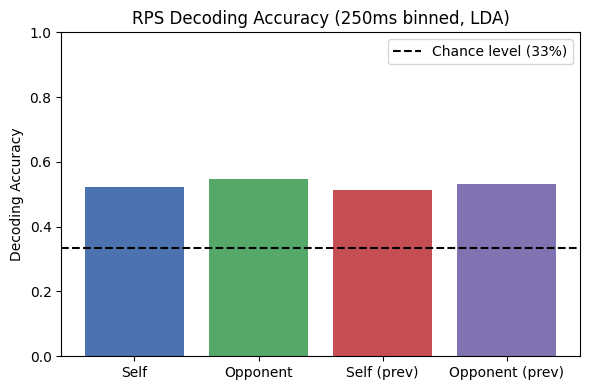

In [37]:
import matplotlib.pyplot as plt

labels = ["Self", "Opponent", "Self (prev)", "Opponent (prev)"]
values = [acc_self, acc_other, acc_self_prev, acc_other_prev]

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.axhline(1/3, color="k", linestyle="--", label="Chance level (33%)")

plt.ylabel("Decoding Accuracy")
plt.title("RPS Decoding Accuracy (250ms binned, LDA)")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
X_dec = epochs_decision.get_data()
y_dec_self = epochs_decision.metadata["player1_resp"].to_numpy()
y_dec_opponent = epochs_decision.metadata["player2_resp"].to_numpy()


from mne.decoding import SlidingEstimator, cross_val_multiscore
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

clf = LogisticRegression(max_iter=1000, solver="lbfgs")

time_decod = SlidingEstimator(
    clf,
    scoring="accuracy",
    n_jobs=1  # oder -1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scores_dec_self = cross_val_multiscore(time_decod, X_dec, y_dec_self, cv=cv)
scores_dec_opponent = cross_val_multiscore(time_decod, X_dec, y_dec_opponent, cv=cv)
mean_dec_self = scores_dec_self.mean(axis=0)
mean_dec_opponent = scores_dec_opponent.mean(axis=0)

100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  232.57it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  234.88it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  287.27it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  252.71it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  257.29it/s]
c:\Users\hugoh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
100%|██████████| Fitting SlidingEstimator : 564/564 [00:08<00:00,   68.15it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:07<00:00,   72.99it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:07<00:00,   75.00it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:07<00:00,   72.41it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:07<00:00,

Text(0.5, 1.0, 'Rock–Paper–Scissors decoding over time')

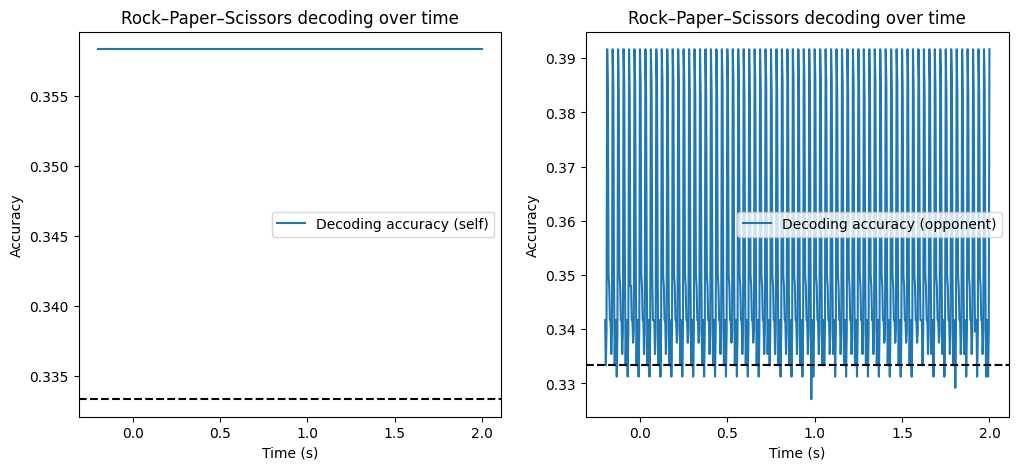

In [30]:
import matplotlib.pyplot as plt
times = epochs.times  # in Sekunden

fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(epochs_decision.times, mean_dec_self, label="Decoding accuracy (self)")
ax[1].plot(epochs_decision.times, mean_dec_opponent, label="Decoding accuracy (opponent)")
ax[0].axhline(1/3, color="k", linestyle="--")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].set_title("Rock–Paper–Scissors decoding over time")   
ax[1].axhline(1/3, color="k", linestyle="--")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].set_title("Rock–Paper–Scissors decoding over time")   


## Many subjects

Verarbeite sub-01...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761\sub-01\eeg\sub-01_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7514111  =      0.000 ...  3669.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 9 columns
480 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 1332 original time points

C:\Users\hugoh\AppData\Local\Temp\ipykernel_28244\2249852503.py:51: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-0.199219 s)
  epochs_decision = epochs.copy().crop(tmin=-0.2, tmax=2.0)
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  332.05it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  313.29it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  339.00it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  359.01it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  365.56it/s]
c:\Users\hugoh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  252.49it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00, 

Verarbeite sub-02...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761\sub-02\eeg\sub-02_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7020543  =      0.000 ...  3428.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 9 columns
472 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 472 events and 1332 original time points

C:\Users\hugoh\AppData\Local\Temp\ipykernel_28244\2249852503.py:51: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-0.199219 s)
  epochs_decision = epochs.copy().crop(tmin=-0.2, tmax=2.0)
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  378.90it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  384.85it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  356.77it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  409.29it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  362.11it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  383.73it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  316.59it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  343.48it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  402.46it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [

Verarbeite sub-03...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761\sub-03\eeg\sub-03_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7712767  =      0.000 ...  3766.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
483 events found on stim channel Status
Event IDs: [  511  4351 15103]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65791 (consider using initial_event=True to detect this event)
483 events found on stim channel Status
Event IDs: [  511  4351 15103]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 9 columns
478 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 478 events a

...

C:\Users\hugoh\AppData\Local\Temp\ipykernel_28244\2249852503.py:51: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-0.199219 s)
  epochs_decision = epochs.copy().crop(tmin=-0.2, tmax=2.0)
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  345.37it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  356.30it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  360.79it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  359.29it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  345.97it/s]
c:\Users\hugoh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  254.11it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00, 

Verarbeite sub-09...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761\sub-09\eeg\sub-09_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6166527  =      0.000 ...  3011.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
481 events found on stim channel Status
Event IDs: [  511 15103]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
481 events found on stim channel Status
Event IDs: [  511 15103]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 9 columns
479 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 479 events and 1332 orig

C:\Users\hugoh\AppData\Local\Temp\ipykernel_28244\2249852503.py:51: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-0.199219 s)
  epochs_decision = epochs.copy().crop(tmin=-0.2, tmax=2.0)
c:\Users\hugoh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  255.32it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  261.22it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  254.24it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  372.57it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  227.92it/s]
c:\Users\hugoh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated 

Verarbeite sub-11...
Extracting BDF parameters from c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\MNE-sample-data\ds006761\sub-11\eeg\sub-11_task-RPS_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6174719  =      0.000 ...  3015.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 80639 (consider using initial_event=True to detect this event)
480 events found on stim channel Status
Event IDs: [511]
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Adding metadata with 9 columns
476 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 476 events and 1332 original time points

C:\Users\hugoh\AppData\Local\Temp\ipykernel_28244\2249852503.py:51: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-0.199219 s)
  epochs_decision = epochs.copy().crop(tmin=-0.2, tmax=2.0)
c:\Users\hugoh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  273.63it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  306.32it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00,  314.64it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  281.84it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  256.59it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:02<00:00,  277.11it/s]
100%|██████████| Fitting SlidingEstimator : 564/564 [00:01<00:00, 

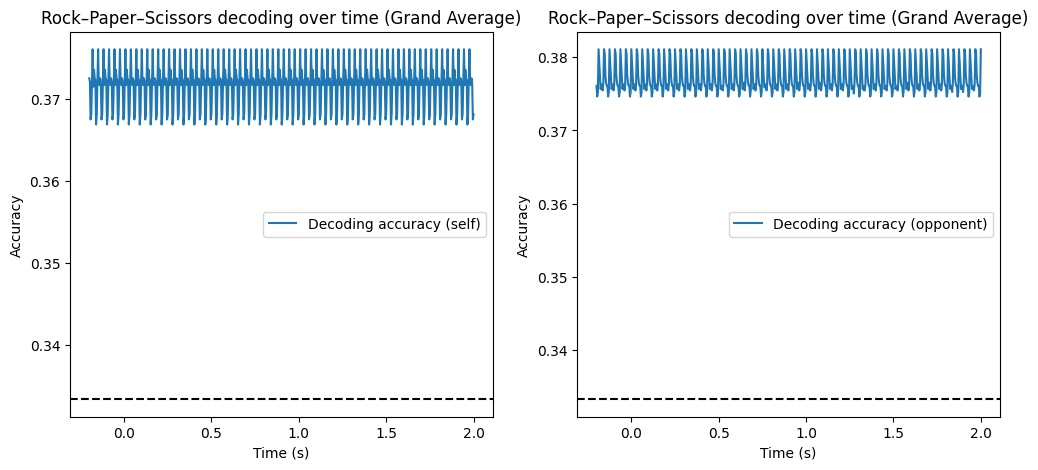